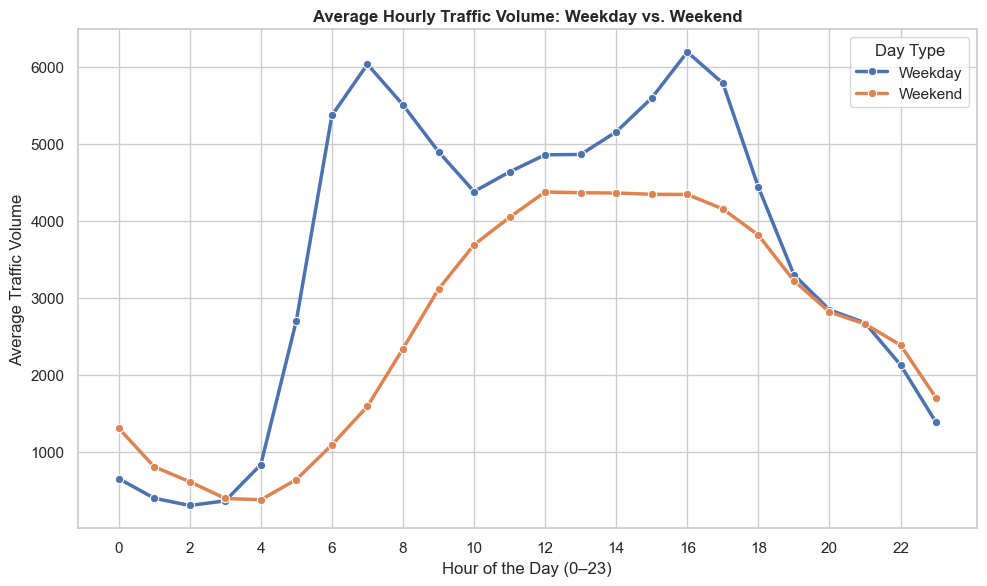

C:\Users\vimih\AppData\Local\Temp\ipykernel_17464\1468074646.py:201: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


In [16]:
import logging
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set up module-level logger (never use root logger directly)
logger = logging.getLogger(__name__)


def setup_visualization_logging():
    """Configures logging handlers and formatters if running script directly.

    Logs to both console and 'pipeline.log'.
    """
    logger.setLevel(logging.DEBUG)

    # Prevent adding duplicate handlers if logger is already configured
    if not logger.handlers:
        formatter = logging.Formatter(
            '%(asctime)s - %(levelname)s - %(name)s - %(message)s',
            datefmt='%Y-%m-%d %H:%M:%S',
        )

        # File Handler
        file_handler = logging.FileHandler('pipeline.log', mode='a')
        file_handler.setFormatter(formatter)
        file_handler.setLevel(logging.INFO)

        # Console Handler
        console_handler = logging.StreamHandler()
        console_handler.setFormatter(formatter)
        console_handler.setLevel(logging.INFO)

        logger.addHandler(file_handler)
        logger.addHandler(console_handler)


def generate_visualizations(
    input_filepath='featured_traffic_data.csv', output_dir='figures'
):
    """Generates three key Matplotlib visualisations to reveal traffic patterns,

    saves them to disk, and logs each saved figure.
    """
    logger.info(
        '================== Starting Visualization Phase'
        ' =================='
    )

    # 1. Load Data with Error Handling
    try:
        if not os.path.exists(input_filepath):
            raise FileNotFoundError(
                f"Input file '{input_filepath}' does not exist."
            )

        df = pd.read_csv(input_filepath)
        logger.info(
            f"Successfully loaded featured dataset '{input_filepath}' for"
            ' visualization.'
        )
    except Exception as e:
        logger.error(
            f'Failed to load dataset for visualization: {e}', exc_info=True
        )
        return

    # Create output directory for figures if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Set consistent visualization styling
    sns.set_theme(style='whitegrid')
    plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})

    # -------------------------------------------------------------------------
    # Visualization 1: Hourly Traffic Demand (Weekday vs. Weekend)
    # -------------------------------------------------------------------------
    try:
        fig, ax = plt.subplots(figsize=(10, 6))

        # Ensure date_time is datetime type
        df['date_time'] = pd.to_datetime(df['date_time'])

        # Extract hour if missing
        if 'hour' not in df.columns:
            df['hour'] = df['date_time'].dt.hour

        # Create day_type reliably regardless of whether is_weekend is bool, int, or string
        df['day_type'] = np.where(
            df['date_time'].dt.dayofweek >= 5, 'Weekend', 'Weekday'
        )

        # Aggregate mean traffic volume by hour and day_type
        hourly_traffic = (
            df.groupby(['hour', 'day_type'])['traffic_volume']
            .mean()
            .reset_index()
        )

        # Plot the lines
        sns.lineplot(
            data=hourly_traffic,
            x='hour',
            y='traffic_volume',
            hue='day_type',
            marker='o',
            linewidth=2.5,
            ax=ax,
        )

        # Formatting titles and axes
        ax.set_title(
            'Average Hourly Traffic Volume: Weekday vs. Weekend',
            fontweight='bold',
        )
        ax.set_xlabel('Hour of the Day (0–23)')
        ax.set_ylabel('Average Traffic Volume')
        ax.set_xticks(range(0, 24, 2))
        ax.legend(title='Day Type')

        # Save figure to disk
        fig1_path = os.path.join(
            output_dir, '01_hourly_traffic_weekday_vs_weekend.png'
        )
        plt.tight_layout()
        plt.savefig(fig1_path, dpi=300)

        # If running in Jupyter Notebook, call plt.show() BEFORE plt.close()
        plt.show()
        plt.close(fig)

        # MANDATORY LOGGING REQUIREMENT
        logger.info(f"Successfully saved figure: '{fig1_path}'")

    except Exception as e:
        logger.error(
            f'Failed to generate Figure 1 (Hourly Traffic): {e}', exc_info=True
        )

    # -------------------------------------------------------------------------
    # Visualization 2: Temperature vs. Traffic Volume by Congestion Category
    # -------------------------------------------------------------------------
    try:
        fig, ax = plt.subplots(figsize=(10, 6))

        # Convert Kelvin to Celsius if temp is in Kelvin
        df_plot = df.copy()
        if 'temp' in df_plot.columns and df_plot['temp'].mean() > 200:
            df_plot['temp_celsius'] = df_plot['temp'] - 273.15
        else:
            df_plot['temp_celsius'] = df_plot.get('temp', np.nan)

        # Plot scatter / KDE relationship
        sns.scatterplot(
            data=df_plot,
            x='temp_celsius',
            y='traffic_volume',
            alpha=0.2,
            s=20,
            color='teal',
            ax=ax,
        )

        ax.set_title(
            'Relationship Between Temperature (°C) and Traffic Volume',
            fontweight='bold',
        )
        ax.set_xlabel('Temperature (°C)')
        ax.set_ylabel('Traffic Volume')

        fig2_path = os.path.join(output_dir, '02_temperature_vs_traffic.png')
        plt.tight_layout()
        plt.savefig(fig2_path, dpi=300)
        plt.close()

        # MANDATORY LOGGING REQUIREMENT
        logger.info(f"Successfully saved figure: '{fig2_path}'")

    except Exception as e:
        logger.error(
            f'Failed to generate Figure 2 (Temperature vs Traffic): {e}',
            exc_info=True,
        )

    # -------------------------------------------------------------------------
    # Visualization 3: Distribution of Traffic Volume Across Main Weather Categories
    # -------------------------------------------------------------------------
    try:
        fig, ax = plt.subplots(figsize=(12, 6))

        # Sort order by median traffic volume for clean presentation
        weather_order = (
            df.groupby('weather_main')['traffic_volume']
            .median()
            .sort_values(ascending=False)
            .index
        )

        sns.boxplot(
            data=df,
            x='weather_main',
            y='traffic_volume',
            order=weather_order,
            palette='Blues_r',
            ax=ax,
        )

        ax.set_title(
            'Traffic Volume Distribution across Main Weather Categories',
            fontweight='bold',
        )
        ax.set_xlabel('Weather Condition')
        ax.set_ylabel('Traffic Volume')
        plt.xticks(rotation=45)

        fig3_path = os.path.join(output_dir, '03_traffic_by_weather_main.png')
        plt.tight_layout()
        plt.savefig(fig3_path, dpi=300)
        plt.close()

        # MANDATORY LOGGING REQUIREMENT
        logger.info(f"Successfully saved figure: '{fig3_path}'")

    except Exception as e:
        logger.error(
            f'Failed to generate Figure 3 (Traffic by Weather): {e}',
            exc_info=True,
        )

    logger.info(
        '================== Visualization Phase Completed'
        ' =================='
    )


if __name__ == '__main__':
    setup_visualization_logging()
    generate_visualizations()